In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("sid4sal/alpaca-dataset-small")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'alpaca-dataset-small' dataset.
Path to dataset files: /kaggle/input/alpaca-dataset-small


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix , classification_report

import tensorflow as tf
import tensorflow as keras
from keras import callbacks , layers
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.models import Sequential
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam , Adamax
from tensorflow.keras.layers import Dense , MaxPooling2D , Flatten , BatchNormalization , Conv2D , Dropout
import warnings
warnings.filterwarnings("ignore")

In [3]:
File = '/kaggle/input/alpaca-dataset-small/dataset'
path = []
label = []

folder = os.listdir(File)
for labels in folder:
    path_file= os.path.join(File , labels)
    name_file = os.listdir(path_file)

    for img in name_file:
        path_img= os.path.join(path_file , img)

        path.append(path_img)
        label.append(labels)

In [4]:
Path = pd.Series(path , name='Image_Path')
Label = pd.Series(label , name='Image_Label')
df = pd.concat([Path, Label] , axis=1)

In [5]:
df

,Image_Path,Image_Label
0,/kaggle/input/alpaca-dataset-small/dataset/not...,not alpaca
1,/kaggle/input/alpaca-dataset-small/dataset/not...,not alpaca
2,/kaggle/input/alpaca-dataset-small/dataset/not...,not alpaca
3,/kaggle/input/alpaca-dataset-small/dataset/not...,not alpaca
4,/kaggle/input/alpaca-dataset-small/dataset/not...,not alpaca
...,...,...
322,/kaggle/input/alpaca-dataset-small/dataset/alp...,alpaca
323,/kaggle/input/alpaca-dataset-small/dataset/alp...,alpaca
324,/kaggle/input/alpaca-dataset-small/dataset/alp...,alpaca
325,/kaggle/input/alpaca-dataset-small/dataset/alp...,alpaca


In [6]:
df['Image_Label'].value_counts()

,count
Image_Label,
not alpaca,185
alpaca,142


In [7]:
from imblearn.over_sampling import RandomOverSampler

X = df[['Image_Path']]
y = df['Image_Label']

ros = RandomOverSampler(sampling_strategy='auto', random_state=42)
X_resampled, y_resampled = ros.fit_resample(X, y)

df_all = pd.DataFrame({
    'Image_Path':  X_resampled['Image_Path'],'Image_Label': y_resampled
})

print(df_all['Image_Label'].value_counts())

Image_Label
not alpaca    185
alpaca        185
Name: count, dtype: int64


In [8]:
df_train , df_test = train_test_split(df_all , test_size=0.2 , random_state=42 , shuffle=True)

In [9]:
df_train

,Image_Path,Image_Label
345,/kaggle/input/alpaca-dataset-small/dataset/alp...,alpaca
192,/kaggle/input/alpaca-dataset-small/dataset/alp...,alpaca
75,/kaggle/input/alpaca-dataset-small/dataset/not...,not alpaca
84,/kaggle/input/alpaca-dataset-small/dataset/not...,not alpaca
358,/kaggle/input/alpaca-dataset-small/dataset/alp...,alpaca
...,...,...
71,/kaggle/input/alpaca-dataset-small/dataset/not...,not alpaca
106,/kaggle/input/alpaca-dataset-small/dataset/not...,not alpaca
270,/kaggle/input/alpaca-dataset-small/dataset/alp...,alpaca
348,/kaggle/input/alpaca-dataset-small/dataset/alp...,alpaca


In [10]:
df_test

,Image_Path,Image_Label
327,/kaggle/input/alpaca-dataset-small/dataset/alp...,alpaca
33,/kaggle/input/alpaca-dataset-small/dataset/not...,not alpaca
15,/kaggle/input/alpaca-dataset-small/dataset/not...,not alpaca
314,/kaggle/input/alpaca-dataset-small/dataset/alp...,alpaca
57,/kaggle/input/alpaca-dataset-small/dataset/not...,not alpaca
...,...,...
82,/kaggle/input/alpaca-dataset-small/dataset/not...,not alpaca
94,/kaggle/input/alpaca-dataset-small/dataset/not...,not alpaca
195,/kaggle/input/alpaca-dataset-small/dataset/alp...,alpaca
311,/kaggle/input/alpaca-dataset-small/dataset/alp...,alpaca


In [11]:
df_vaild , df_test = train_test_split(df_test , test_size=0.5 , random_state=42 , shuffle=True)

In [12]:
df_vaild

,Image_Path,Image_Label
314,/kaggle/input/alpaca-dataset-small/dataset/alp...,alpaca
231,/kaggle/input/alpaca-dataset-small/dataset/alp...,alpaca
152,/kaggle/input/alpaca-dataset-small/dataset/not...,not alpaca
305,/kaggle/input/alpaca-dataset-small/dataset/alp...,alpaca
349,/kaggle/input/alpaca-dataset-small/dataset/alp...,alpaca
76,/kaggle/input/alpaca-dataset-small/dataset/not...,not alpaca
63,/kaggle/input/alpaca-dataset-small/dataset/not...,not alpaca
326,/kaggle/input/alpaca-dataset-small/dataset/alp...,alpaca
250,/kaggle/input/alpaca-dataset-small/dataset/alp...,alpaca
90,/kaggle/input/alpaca-dataset-small/dataset/not...,not alpaca


In [13]:
batch_size = 16
img_size= (224,224)

train= ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    zoom_range=0.1,
    brightness_range=[0.85, 1.15],
    fill_mode='nearest'
)

test = ImageDataGenerator(
    rescale=1./255,
)

df_tr = train.flow_from_dataframe(
    df_train,
    x_col='Image_Path',
    y_col='Image_Label',
    target_size=img_size,
    class_mode='binary',
    color_mode='rgb',
    shuffle=True,
    batch_size=batch_size
)

df_va = test.flow_from_dataframe(
    df_vaild ,
    x_col='Image_Path',
    y_col='Image_Label',
    target_size=img_size,
    class_mode='binary',
    color_mode='rgb',
    shuffle=True,
    batch_size=batch_size
)

df_te = test.flow_from_dataframe(
    df_test,
    x_col='Image_Path',
    y_col='Image_Label',
    target_size=img_size,
    class_mode='binary',
    color_mode='rgb',
    shuffle=False,
    batch_size=batch_size
)


Found 296 validated image filenames belonging to 2 classes.
Found 37 validated image filenames belonging to 2 classes.
Found 37 validated image filenames belonging to 2 classes.


In [14]:
img_shape=(224,224,3)

early_stop = EarlyStopping(monitor='val_loss', patience=5 , restore_best_weights=True)

model = Sequential([
    Conv2D(32, (3,3), padding='same', activation='relu' , input_shape=img_shape),
    MaxPooling2D((2,2)),

    Conv2D(64, (3,3), padding='same', activation='relu'),
    MaxPooling2D((2,2)),

    Conv2D(128, (3,3), padding='same', activation='relu'),
    MaxPooling2D((2,2)),

    Flatten(),
    Dense(128, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy' ,'precision' , 'recall'])
model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 100352)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    12,845,184 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,938,561 (49.36 MB)

 Trainable params: 12,938,561 (49.36 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(df_tr, epochs=30, validation_data=df_va , callbacks=[early_stop])

Epoch 1/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 13s 512ms/step - accuracy: 0.4966 - loss: 0.8420 - precision: 0.4974 - recall: 0.6486 - val_accuracy: 0.5135 - val_loss: 0.6931 - val_precision: 0.5135 - val_recall: 1.0000
Epoch 2/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 7s 369ms/step - accuracy: 0.5236 - loss: 0.6934 - precision: 0.5176 - recall: 0.6959 - val_accuracy: 0.5405 - val_loss: 0.6841 - val_precision: 0.5278 - val_recall: 1.0000
Epoch 3/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 6s 325ms/step - accuracy: 0.5101 - loss: 0.6936 - precision: 0.5072 - recall: 0.7095 - val_accuracy: 0.6757 - val_loss: 0.6133 - val_precision: 1.0000 - val_recall: 0.3684
Epoch 4/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 7s 370ms/step - accuracy: 0.6486 - loss: 0.6436 - precision: 0.6964 - recall: 0.5270 - val_accuracy: 0.7297 - val_loss: 0.5431 - val_precision: 0.7647 - val_recall: 0.6842
Epoch 5/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 6s 322ms/step - accuracy: 0.6554 - loss: 0.6429 - precision: 0.7170 - recall: 0.5135 - val_accuracy: 0.6757 - val_loss: 0

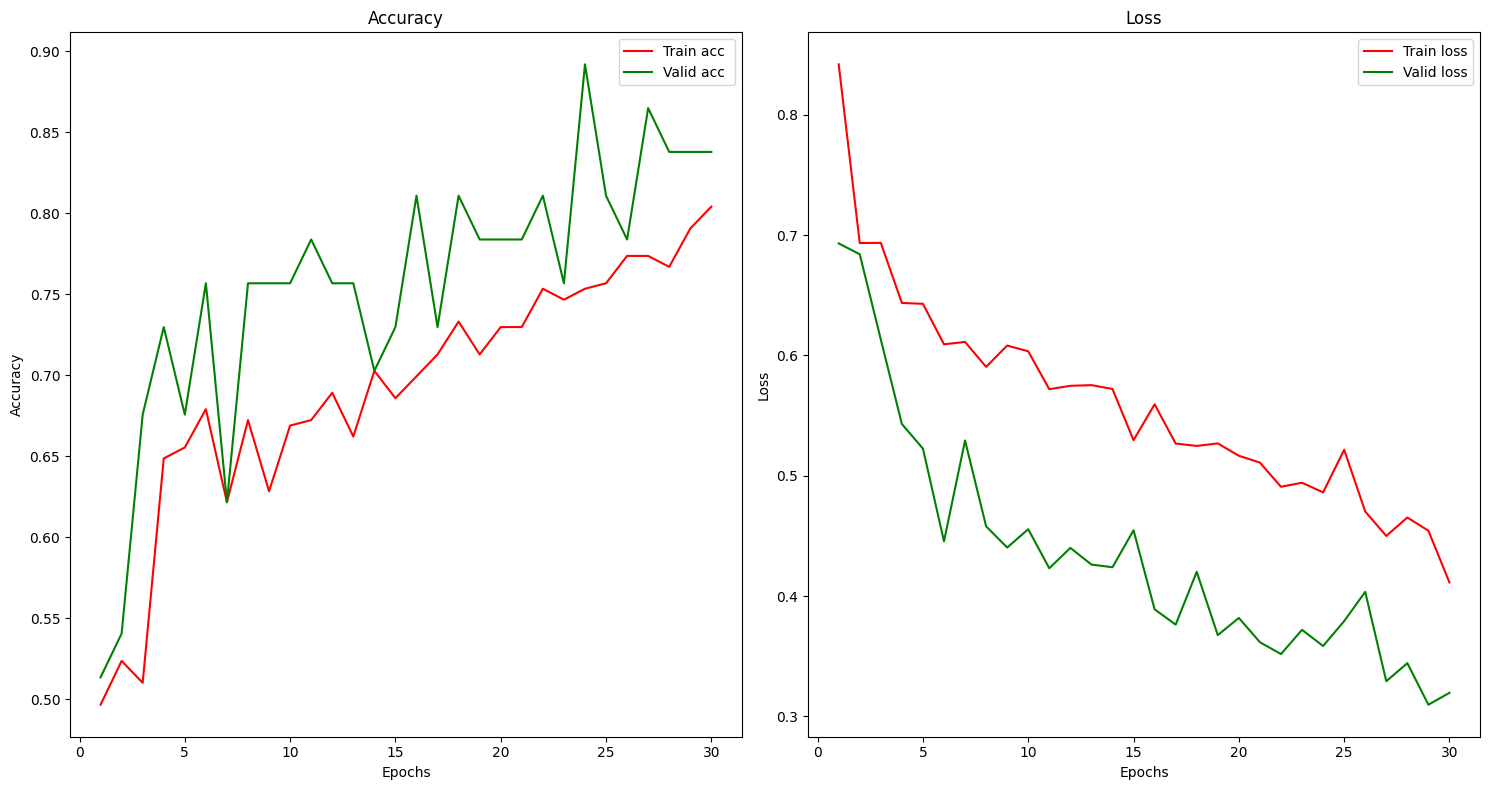

In [ ]:
tr_acc = history.history['accuracy']
tr_loss = history.history['loss']
val_acc = history.history['val_accuracy']
val_loss = history.history['val_loss']

epochs = [i+1 for i in range(len(tr_acc))]

plt.figure(figsize=(15,8))
plt.subplot(1,2,1)
plt.plot(epochs, tr_acc , 'r' , label='Train acc')
plt.plot(epochs , val_acc , 'g' , label='Valid acc ')
plt.title("Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1,2,2)
plt.plot(epochs , tr_loss , 'r' , label='Train loss')
plt.plot(epochs , val_loss , 'g' , label='Valid loss')
plt.title("Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
tr_score = model.evaluate(df_tr , verbose=1)
te_score = model.evaluate(df_te , verbose=1)
va_score = model.evaluate(df_va , verbose=1)

print(' train_score : ' , tr_score)
print(' test_score  : ' , te_score)
print(' valid_score : ' , va_score)

19/19 ━━━━━━━━━━━━━━━━━━━━ 10s 527ms/step - accuracy: 0.7770 - loss: 0.4124 - precision: 0.8361 - recall: 0.6892
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 132ms/step - accuracy: 0.7838 - loss: 0.4112 - precision: 0.9167 - recall: 0.6111
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step - accuracy: 0.8378 - loss: 0.3098 - precision: 1.0000 - recall: 0.6842
 train_score :  [0.412444144487381, 0.7770270109176636, 0.8360655903816223, 0.6891891956329346]
 test_score  :  [0.4112105071544647, 0.7837837934494019, 0.9166666865348816, 0.6111111044883728]
 valid_score :  [0.30975523591041565, 0.837837815284729, 1.0, 0.6842105388641357]


In [ ]:
y_pred_probs = model.predict(df_te)
y_pred = (y_pred_probs > 0.5).astype(int)
y_true = df_te.classes

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step 


Text(95.72222222222221, 0.5, 'Actual Label')

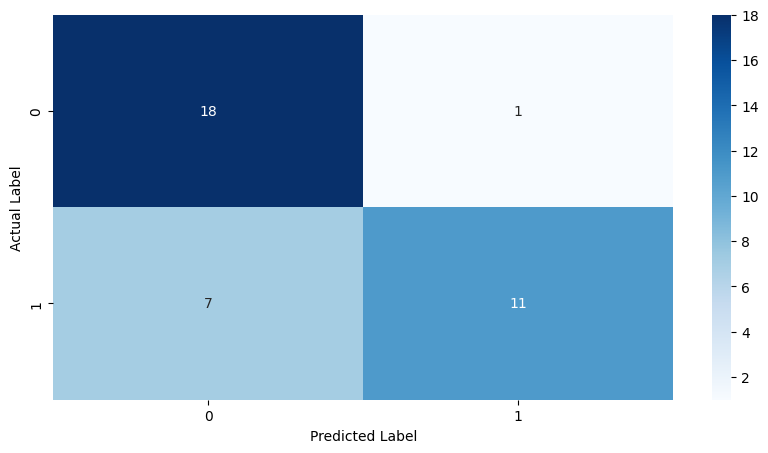

In [ ]:
plt.figure(figsize=(10,5))
cm = confusion_matrix(y_true,y_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')

In [ ]:
print(classification_report(y_true, y_pred, target_names=list(df_te.class_indices.keys())))

              precision    recall  f1-score   support

      alpaca       0.72      0.95      0.82        19
  not alpaca       0.92      0.61      0.73        18

    accuracy                           0.78        37
   macro avg       0.82      0.78      0.78        37
weighted avg       0.82      0.78      0.78        37



In [62]:
from tensorflow.keras.applications import InceptionV3

base_model=InceptionV3(
    include_top=False,
    weights="imagenet",
    input_shape=(224,224,3))

model=Sequential([
    base_model,
    Flatten(),
    Dense(256,activation='relu'),
    Dense(64,activation='relu'),
    Dense(1,activation='sigmoid')
])
model.compile(Adamax(learning_rate= 0.001), loss= 'binary_crossentropy', metrics= ['accuracy'])
model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ inception_v3 (Functional)       │ (None, 5, 5, 2048)     │    21,802,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 51200)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 256)            │    13,107,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 34,926,753 (133.23 MB)

 Trainable params: 34,892,321 (133.10 MB)

 Non-trainable params: 34,432 (134.50 KB)

In [63]:
history= model.fit(df_tr, epochs=10, validation_data=df_va)

Epoch 1/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 113s 3s/step - accuracy: 0.7095 - loss: 1.5381 - val_accuracy: 0.5405 - val_loss: 8.5161
Epoch 2/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 7s 354ms/step - accuracy: 0.8277 - loss: 0.5014 - val_accuracy: 0.5405 - val_loss: 27.7780
Epoch 3/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 8s 417ms/step - accuracy: 0.8919 - loss: 0.3277 - val_accuracy: 0.5405 - val_loss: 83.4238
Epoch 4/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 7s 361ms/step - accuracy: 0.8919 - loss: 0.2957 - val_accuracy: 0.5405 - val_loss: 14.0626
Epoch 5/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 8s 425ms/step - accuracy: 0.8885 - loss: 0.2908 - val_accuracy: 0.5946 - val_loss: 8.6678
Epoch 6/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 7s 389ms/step - accuracy: 0.9392 - loss: 0.1521 - val_accuracy: 0.7027 - val_loss: 7.3875
Epoch 7/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 7s 365ms/step - accuracy: 0.9730 - loss: 0.0984 - val_accuracy: 0.7027 - val_loss: 4.1925
Epoch 8/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 11s 408ms/step - accuracy: 0.9730 - loss: 0.0835 - val_accuracy:

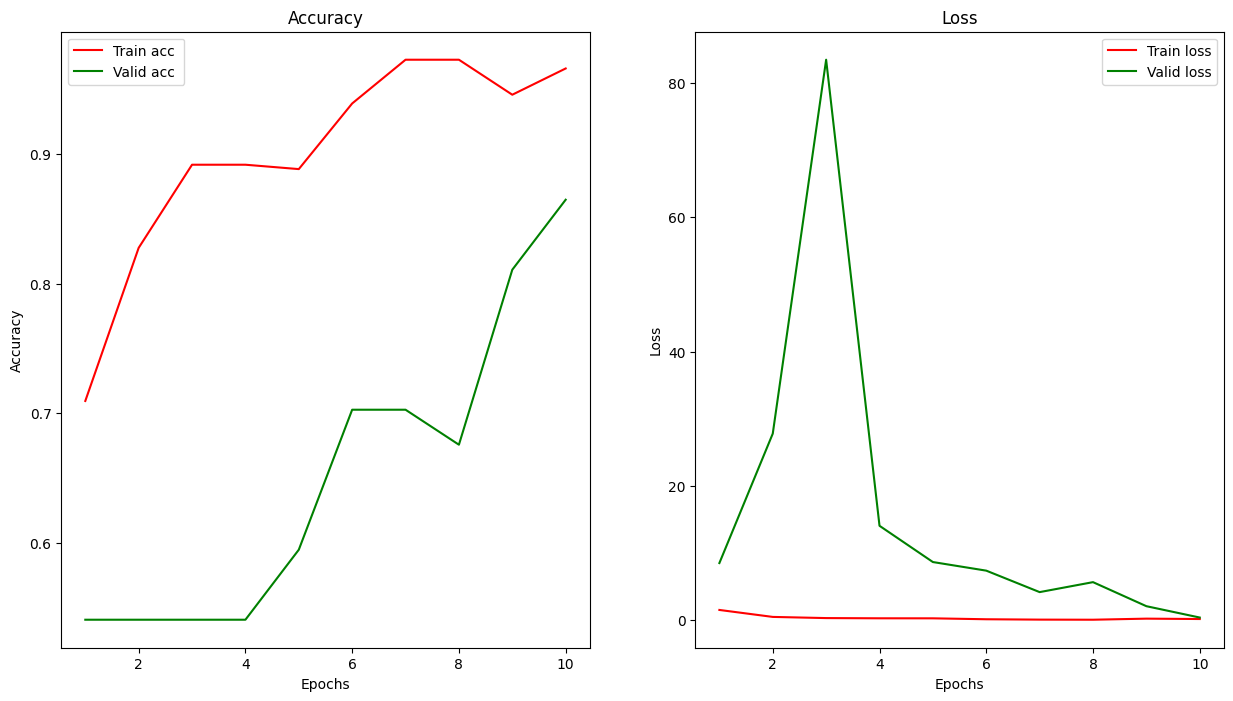

In [67]:
tr_acc = history.history['accuracy']
tr_loss = history.history['loss']
val_acc = history.history['val_accuracy']
val_loss = history.history['val_loss']

epochs = [i+1 for i in range(len(tr_acc))]

plt.figure(figsize=(15,8))
plt.subplot(1,2,1)
plt.plot(epochs, tr_acc , 'r' , label='Train acc')
plt.plot(epochs , val_acc , 'g' , label='Valid acc ')
plt.title("Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1,2,2)
plt.plot(epochs , tr_loss , 'r' , label='Train loss')
plt.plot(epochs , val_loss , 'g' , label='Valid loss')
plt.title("Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

plt.show()

In [68]:
tr_score = model.evaluate(df_tr , verbose=1)
te_score = model.evaluate(df_te , verbose=1)
va_score = model.evaluate(df_va , verbose=1)

print(' train_score : ' , tr_score)
print(' test_score  : ' , te_score)
print(' valid_score : ' , va_score)

19/19 ━━━━━━━━━━━━━━━━━━━━ 10s 541ms/step - accuracy: 0.9595 - loss: 0.1228
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 95ms/step - accuracy: 0.9730 - loss: 0.2623 
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step - accuracy: 0.8649 - loss: 0.4077
 train_score :  [0.12282049655914307, 0.9594594836235046]
 test_score  :  [0.2622939348220825, 0.9729729890823364]
 valid_score :  [0.40765580534935, 0.8648648858070374]


In [64]:
y_pred_probs = model.predict(df_te)
y_pred = (y_pred_probs > 0.5).astype(int)
y_true = df_te.classes

3/3 ━━━━━━━━━━━━━━━━━━━━ 13s 3s/step


Text(95.72222222222221, 0.5, 'Actual Label')

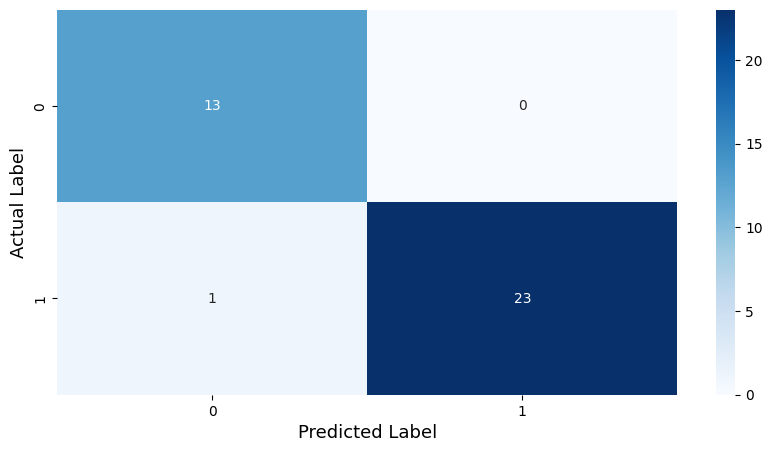

In [65]:
plt.figure(figsize=(10,5))
cm = confusion_matrix(y_true,y_pred)


sns.heatmap(cm,annot=True , cmap="Blues")

plt.xlabel('Predicted Label',fontsize=13)
plt.ylabel('Actual Label',fontsize=13)

In [66]:
print(classification_report(y_true, y_pred, target_names=list(df_te.class_indices.keys())))

              precision    recall  f1-score   support

      alpaca       0.93      1.00      0.96        13
  not alpaca       1.00      0.96      0.98        24

    accuracy                           0.97        37
   macro avg       0.96      0.98      0.97        37
weighted avg       0.97      0.97      0.97        37

